In [1]:
## Make Suffecienct SHAPIQ implimentation 

In [2]:
import os, sys, pickle, importlib, numpy as np, pandas as pd

REPO = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
import eigen_steering
importlib.reload(eigen_steering)
eigen_steering.WEIGHTS_PATH = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/pytorch_base_model/model_fold_0.safetensors'
eigen_steering.RESULTS_DIR = os.path.join(REPO, 'models')
from eigen_steering import EigenMap

lib_path = os.path.join(REPO, 'virtual_perturbations', 'libraries', 'hippo_target_library.pkl')
with open(lib_path, 'rb') as f:
    lib = pickle.load(f)

df = lib['df']
focus_tfs = lib['focus_tfs']

CT = {'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
em = EigenMap(model_names=CT, device='cuda')

em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

raw = np.load(lib['attr_npz_path'])
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna()
n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
raw_indices = np.arange(n)[keep]
del df_full

ohe = em.X.numpy()
idxs = df.seq_idx.values
npz_idxs = raw_indices[idxs]
for ct in CT:
    hyp = raw[f'attr_{ct}'][npz_idxs]
    em.attr_hyp[ct] = hyp
    em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][npz_idxs]

em.motif_hits = lib['motif_hits']
em.eigen_results = lib['eigen_results']

print(f'Loaded {len(df)} sequences')

AlphaGenome patches applied (all functional activations -> nn.Module).
EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
Loaded 1059 sequences, X shape: torch.Size([1059, 4, 281])
Loaded 1059 sequences


In [3]:
# Run sufficiency-mode SHAPIQ
n_rep = 20
seed = 42
max_order = 4

sii_suf = em.shapley_interaction_index(
    seq_idx=None, max_order=max_order,
    n_rep=n_rep, batch_size=516, random_state=seed,
    mode='sufficiency',
)

# Collect into flat dataframe
rows = []
for si, res in enumerate(sii_suf):
    if res is None:
        continue
    for act, act_res in res.items():
        if act_res['n_motifs'] == 0:
            continue
        motif_names = act_res['motifs']
        for interaction_key, ct_scores in act_res['interactions'].items():
            order = len(interaction_key)
            if order < 1:
                continue
            names = '+'.join(motif_names[i] for i in interaction_key)
            for ct, score in ct_scores.items():
                rows.append({
                    'seq_idx': si,
                    'annotation_ct': act,
                    'scoring_ct': ct,
                    'interaction': interaction_key,
                    'motif_names': names,
                    'order': order,
                    'sii_score': score,
                    'EI_1_vxr': df.iloc[si]['EI_1 var x r'],
                    'condition': df.iloc[si]['condition'],
                })

suf_df = pd.DataFrame(rows)
print(f'{len(suf_df)} rows, {suf_df.seq_idx.nunique()} sequences')
print(f'Orders: {suf_df.order.value_counts().to_dict()}')

/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/Hippo_agft_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Loading HepG2: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/checkpoints/best_stage2.pt
  Loading K562: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/checkpoints/best_stage2.pt
  shapley (sufficiency): 1059/1059 sequences
7238 rows, 1059 sequences
Orders: {1: 4704, 2: 1928, 3: 502, 4: 104}


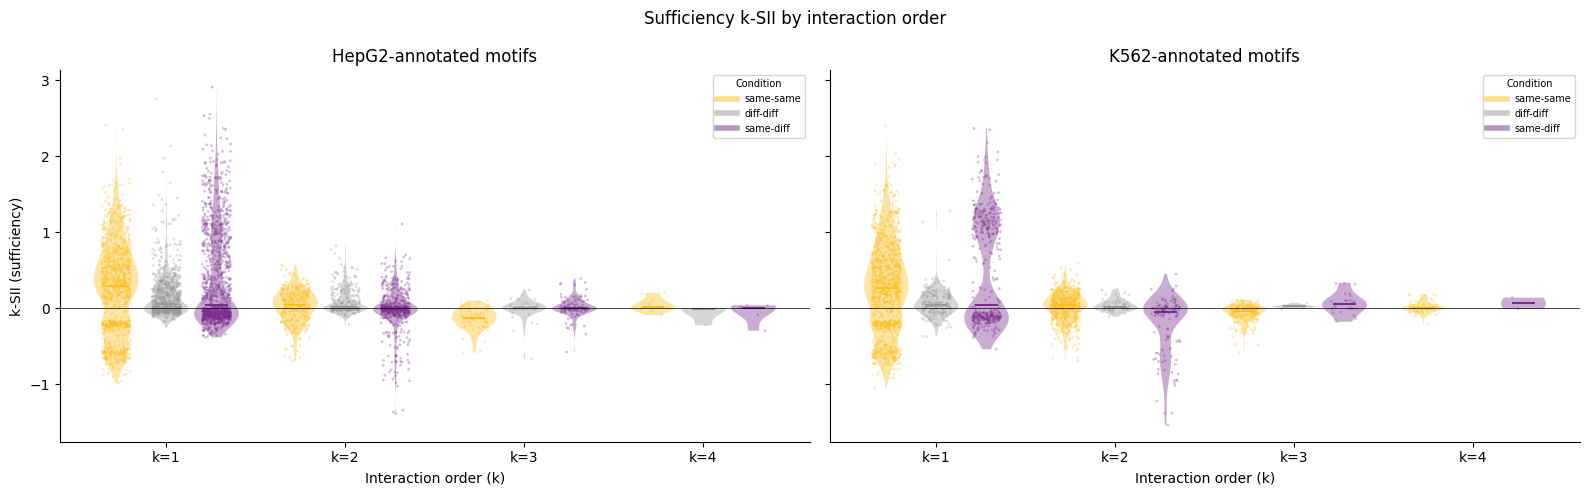

In [4]:
import matplotlib.pyplot as plt

# k-SII by interaction order, per annotation ct
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
orders = sorted(suf_df.order.unique())

cond_style = {
    'same-same': ('#fcbf20', -0.28, 'same-same'),
    'diff-diff': ('#999999', 0.0, 'diff-diff'),
    'same-diff': ('#7b2d8e', 0.28, 'same-diff'),
}

for ax_i, act in enumerate(['HepG2', 'K562']):
    ax = axes[ax_i]
    sub_act = suf_df[suf_df.annotation_ct == act]

    rng = np.random.default_rng(42)
    for cond, (color, xoff, label) in cond_style.items():
        sub = sub_act[sub_act.condition == cond]
        violin_data = []
        valid_positions = []
        for o in orders:
            vals = sub.loc[sub.order == o, 'sii_score'].values
            if len(vals) > 1:
                violin_data.append(vals)
                valid_positions.append(o + xoff)
        if violin_data:
            parts = ax.violinplot(
                violin_data, positions=valid_positions,
                widths=0.25, showmedians=True, showextrema=False,
            )
            for pc in parts['bodies']:
                pc.set_facecolor(color)
                pc.set_alpha(0.4)
            parts['cmedians'].set_color(color)
            parts['cmedians'].set_linewidth(1.5)
        for o in orders:
            vals = sub.loc[sub.order == o, 'sii_score'].values
            if len(vals) == 0:
                continue
            jit = rng.uniform(-0.08, 0.08, len(vals))
            ax.scatter(o + xoff + jit, vals, s=4, alpha=0.3,
                       color=color, edgecolors='none', zorder=2)
        ax.plot([], [], color=color, lw=4, alpha=0.5, label=label)

    ax.axhline(0, c='k', lw=0.5)
    ax.set_xticks(orders)
    ax.set_xticklabels([f'k={o}' for o in orders])
    ax.set_xlabel('Interaction order (k)')
    ax.set_title(f'{act}-annotated motifs')
    ax.legend(fontsize=7, title='Condition', title_fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('k-SII (sufficiency)')
plt.suptitle('Sufficiency k-SII by interaction order', fontsize=12)
plt.tight_layout()
plt.show()